# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-03: DLCN Phase-3 Preprocessing

### What this notebook does
Maps the DLCN (Dynamic Lighting Conditions at Night) dataset into the unified Phase-3 schema: one consolidated HDF5 for the dataset with one group per recording, preserving the raw model inputs and labels and enriching them with quality and metadata fields, ready for training the Phase-3 SOTA models (a multi-task, waveform-reconstruction network with heart-rate and respiratory-rate heads).

### Why this differs from Phase 2
Phase 2 extracted hand-crafted 1D ensemble signals (POS/CHROM/GREEN) from video and stored them for classical or lightweight models. Phase 3 targets end-to-end learned models (PhysFormer / VitalLens-2 style) that consume frames directly and reconstruct physiological waveforms. The preprocessing therefore preserves raw frames and raw labels (featurization such as DiffNormalized or Standardized frame transforms is deferred to the training data loader), and records per-recording quality so training can weight or mask rather than silently drop data.

### DLCN role in Phase 3
DLCN provides face frames, a frame-synced BVP pulse waveform, and 1 Hz HR and SpO2 references, under nighttime dynamic lighting. It has no respiration channel and no ECG. It therefore supervises the HR head (via the BVP waveform) and serves as a held-out low-light robustness set; its RR label is absent and is masked in the multi-task loss. See NB_P3_02 for the evidence behind these decisions.


### Pipeline
DLCN P{id}_{cond}.h5 (imgs, bvp, hr, spo2)
  -> parse subject / lighting scenario / state from filename
  -> assess quality (cardiac SQI, HR drift, reference completeness, frame integrity, duration)
  -> assemble unified record (raw frames + raw BVP label + HR + SpO2 + availability flags + quality + metadata)
  -> write one group per recording into the consolidated per-dataset Phase-3 HDF5
  -> append a row to the processing log CSV

### Unified Phase-3 schema (v1)
Every Phase-3 dataset is packaged as one consolidated HDF5 with one group per recording, so a single training loader can consume all of them and the file count stays under Kaggle's 1000-file limit. Fields absent in a given dataset are omitted and flagged in the attributes; the multi-task loss masks the corresponding head.

**Datasets (per recording group)**

| name | shape | dtype | DLCN | meaning |
|------|-------|-------|------|---------|
| frames | [T, 128, 128, 3] | uint8 | yes | face frames (model input) |
| bvp | [T] | float32 | yes | frame-synced pulse waveform (HR label) |
| hr | [S] | float32 | yes | reference heart rate, ~1 Hz |
| spo2 | [S] | float32 | yes | reference SpO2, ~1 Hz |
| resp | [T] or [S] | float32 | no (masked) | respiration waveform (RR label) |
| ecg | [E] | float32 | no | ECG when the source provides it |

**Attributes (per recording group)**
- schema_version, dataset, source_file
- subject_id, condition, lighting_scenario, state
- fps, n_frames, duration_s, frame_size
- has_frames, has_bvp, has_hr, has_spo2, has_resp, has_ecg (label availability)
- cardiac_sqi, hr_drift_bpm, hr_nonstationary, ref_complete, frame_ok
- usable (False only for genuine corruption; graded quality is kept, not dropped)

**Design principles**: preserve raw inputs and labels (defer normalization to the loader); make every label optional with an availability flag (masked multi-task supervision); keep quality as graded fields plus a soft cardiac SQI, excluding only true corruption.

In [1]:
import json
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

# Paths (forward slashes work on Windows via pathlib)
DLCN_DIR = Path('G:/rppg/RPPG-DLCN/DLCN')
DATASET_NAME = 'dlcn'
OUT_DIR = Path('G:/rppg/phase3') 
OUT_H5 = OUT_DIR / f'{DATASET_NAME}_phase3.h5'
LOG_PATH = OUT_DIR / f'processing_log_{DATASET_NAME}_phase3.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Acquisition constants (DLCN stores no metadata; see NB_P3_02)
FPS = 30.0
REF_HZ = 1.0
CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ = 0.7, 3.5

# Quality thresholds (first-pass, calibrated in NB_P3_02)
MIN_DURATION_S = 20.0
SQI_FLOOR = 0.10
HR_DRIFT_STATIONARY_BPM = 15.0
FRAME_DARK, FRAME_BRIGHT = 5.0, 250.0

# Output options
SCHEMA_VERSION = 'p3_v1'
TARGET_SIZE = 72
WRITE_FRAMES = True # copy frames into the store (self-contained); large
OVERWRITE = False # skip recordings already written (resumable); True rebuilds them
MAX_RECORDS = None # set to an int for a trial run

print('DLCN dir exists:', DLCN_DIR.exists())
print('Output store:', OUT_H5)

DLCN dir exists: True
Output store: G:\rppg\phase3\dlcn_phase3.h5


In [2]:
def parse_dlcn_name(stem):
    '''Parses a DLCN filename stem P{id}_{cond} into subject, condition, lighting and state.

    Conditions 1-4 are resting, 5-8 are post-exercise; condition c and c+4 share a lighting
    scenario, so lighting is ((c - 1) % 4) + 1.'''
    pid, cond = stem[1:].split('_')
    cond = int(cond)
    lighting = ((cond - 1) % 4) + 1
    state = 'rest' if cond <= 4 else 'post_exercise'
    return pid, cond, lighting, state


def cardiac_metrics(bvp, fps, low=CARDIAC_LOW_HZ, high=CARDIAC_HIGH_HZ):
    '''Returns the cardiac-band spectral HR (bpm) and a 3-bin peak-power fraction SQI from a BVP waveform.'''
    x = np.asarray(bvp, dtype=np.float64)
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan, 0.0
    x = (x - x.mean()) * np.hanning(x.size)
    power = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fps)
    band = (freqs >= low) & (freqs <= high)
    if not band.any() or power[band].sum() <= 0:
        return np.nan, 0.0
    bp = power[band]
    pk = int(np.argmax(bp))
    hr_bpm = float(freqs[band][pk] * 60.0)
    sqi = float(bp[max(0, pk - 1):pk + 2].sum() / bp.sum())
    return hr_bpm, sqi


def assess_quality(frame_mid, bvp, hr, n_frames, fps):
    '''Computes graded quality fields for one recording plus a hard-usable flag for true corruption only.'''
    duration_s = n_frames / fps
    bvp_hr, sqi = cardiac_metrics(bvp, fps)
    hr = np.asarray(hr, dtype=np.float64)
    ref_hr = float(np.mean(hr)) if hr.size else np.nan
    hr_drift = float(np.nanmax(hr) - np.nanmin(hr)) if hr.size > 1 else np.nan
    ref_complete = bool(hr.size >= 0.9 * duration_s)
    brightness = float(np.mean(frame_mid))
    frame_ok = bool(FRAME_DARK <= brightness <= FRAME_BRIGHT)
    hr_nonstationary = bool(np.isfinite(hr_drift) and hr_drift > HR_DRIFT_STATIONARY_BPM)
    usable = bool(duration_s >= MIN_DURATION_S and frame_ok and sqi >= SQI_FLOOR)
    return dict(duration_s=duration_s, cardiac_sqi=sqi, bvp_spectral_hr=bvp_hr, ref_hr=ref_hr,
                hr_drift_bpm=hr_drift, hr_nonstationary=hr_nonstationary, ref_complete=ref_complete,
                brightness=brightness, frame_ok=frame_ok, usable=usable)


def maybe_resize(frames, target):
    '''Returns frames unchanged if already at the target size, else area-resampled to target x target per frame.'''
    if target is None or frames.shape[1] == target:
        return frames
    out = np.empty((frames.shape[0], target, target, frames.shape[3]), dtype=frames.dtype)
    for i in range(frames.shape[0]):
        out[i] = cv2.resize(frames[i], (target, target), interpolation=cv2.INTER_AREA)
    return out

### Single-recording walkthrough
Processes one recording end-to-end and inspects the assembled unified record before running the full batch, so the schema and quality fields can be sanity-checked cheaply.

In [3]:
h5_files = sorted(DLCN_DIR.glob('*.h5'))
print('Recordings found:', len(h5_files))


def build_record(path):
    '''Reads one DLCN file and returns (arrays, attrs) mapped to the unified schema.'''
    pid, cond, lighting, state = parse_dlcn_name(path.stem)
    with h5py.File(path, 'r') as f:
        n_frames = int(f['imgs'].shape[0])
        bvp = f['bvp'][:].astype(np.float32)
        hr = f['hr'][:].astype(np.float32)
        spo2 = f['spo2'][:].astype(np.float32)
        if WRITE_FRAMES:
            frames = f['imgs'][:]
            frame_mid = frames[n_frames // 2]
        else:
            frames = None
            frame_mid = f['imgs'][n_frames // 2]
    q = assess_quality(frame_mid, bvp, hr, n_frames, FPS)
    if frames is not None:
        frames = maybe_resize(frames, TARGET_SIZE)
    attrs = dict(
        schema_version=SCHEMA_VERSION, dataset='DLCN', source_file=path.name,
        subject_id=pid, condition=cond, lighting_scenario=lighting, state=state,
        fps=FPS, n_frames=n_frames, duration_s=q['duration_s'],
        frame_size=int(frames.shape[1]) if frames is not None else TARGET_SIZE,
        has_frames=bool(WRITE_FRAMES), has_bvp=True, has_hr=bool(hr.size),
        has_spo2=bool(spo2.size), has_resp=False, has_ecg=False,
        cardiac_sqi=q['cardiac_sqi'], hr_drift_bpm=q['hr_drift_bpm'],
        hr_nonstationary=q['hr_nonstationary'], ref_complete=q['ref_complete'],
        frame_ok=q['frame_ok'], usable=q['usable'],
        bvp_units_note='raw DLCN BVP, frame-synced; loader applies bandpass and normalize')
    arrays = dict(bvp=bvp, hr=hr, spo2=spo2, frames=frames)
    return arrays, attrs


arrays, attrs = build_record(h5_files[0])
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in attrs.items()}, indent=2, default=str))
print('bvp', arrays['bvp'].shape, 'hr', arrays['hr'].shape, 'spo2', arrays['spo2'].shape,
      'frames', None if arrays['frames'] is None else arrays['frames'].shape)

Recordings found: 780
{
  "schema_version": "p3_v1",
  "dataset": "DLCN",
  "source_file": "P10_1.h5",
  "subject_id": "10",
  "condition": 1,
  "lighting_scenario": 1,
  "state": "rest",
  "fps": 30.0,
  "n_frames": 1801,
  "duration_s": 60.033,
  "frame_size": 72,
  "has_frames": true,
  "has_bvp": true,
  "has_hr": true,
  "has_spo2": true,
  "has_resp": false,
  "has_ecg": false,
  "cardiac_sqi": 0.208,
  "hr_drift_bpm": 8.0,
  "hr_nonstationary": false,
  "ref_complete": true,
  "frame_ok": true,
  "usable": true,
  "bvp_units_note": "raw DLCN BVP, frame-synced; loader applies bandpass and normalize"
}
bvp (1801,) hr (60,) spo2 (60,) frames (1801, 72, 72, 3)


### Write function and batch processing
Writes each unified record as a group inside one consolidated HDF5 on G: (one group per recording), and appends a processing-log row. Frames dominate storage (~55 MB per recording, roughly 45 GB for all 780). The store is opened in append mode and skips groups already present, so a run is resumable; set OVERWRITE=True to rebuild, WRITE_FRAMES=False for a labels-only pass, or MAX_RECORDS for a trial. Only genuinely corrupt recordings are marked not-usable; graded quality is preserved for the training stage to weight or mask. Writing frames with gzip is I/O bound, so a full run takes a while.

In [4]:
def write_group(store, name, arrays, attrs):
    '''Writes one recording as a group with datasets for the present signals and all attributes.'''
    g = store.create_group(name)
    if arrays['frames'] is not None:
        g.create_dataset('frames', data=arrays['frames'], compression='gzip', compression_opts=1)
    g.create_dataset('bvp', data=arrays['bvp'])
    if arrays['hr'].size:
        g.create_dataset('hr', data=arrays['hr'])
    if arrays['spo2'].size:
        g.create_dataset('spo2', data=arrays['spo2'])
    for key, value in attrs.items():
        g.attrs[key] = value


def process_all(files, out_h5, limit=None, overwrite=False):
    '''Processes recordings into one consolidated per-dataset HDF5 (one group each) and returns the log.'''
    subset = files[:limit] if limit else files
    rows = []
    with h5py.File(out_h5, 'a') as store:
        for i, path in enumerate(subset, 1):
            name = path.stem
            if name in store and not overwrite:
                attrs = dict(store[name].attrs)
                attrs['status'] = 'skipped'
                attrs['error'] = ''
            else:
                try:
                    arrays, attrs = build_record(path)
                    if name in store:
                        del store[name]
                    write_group(store, name, arrays, attrs)
                    attrs['status'] = 'ok'
                    attrs['error'] = ''
                except Exception as exc:
                    attrs = dict(source_file=path.name, subject_id='', condition=-1,
                                 lighting_scenario=-1, state='', duration_s=np.nan,
                                 cardiac_sqi=np.nan, hr_drift_bpm=np.nan, hr_nonstationary=False,
                                 ref_complete=False, usable=False, status='error', error=str(exc))
            cols = ('source_file', 'subject_id', 'condition', 'lighting_scenario', 'state',
                    'duration_s', 'cardiac_sqi', 'hr_drift_bpm', 'hr_nonstationary',
                    'ref_complete', 'usable', 'status', 'error')
            rows.append({c: attrs.get(c) for c in cols})
            if i % 50 == 0 or i == len(subset):
                print('  processed', i, '/', len(subset))
    return pd.DataFrame(rows)


log = process_all(h5_files, OUT_H5, limit=MAX_RECORDS, overwrite=OVERWRITE)
log.to_csv(LOG_PATH, index=False)
print('Store:', OUT_H5)
print('Records ok:', int((log.status == 'ok').sum()), '| skipped:', int((log.status == 'skipped').sum()))
print('Usable:', int(log['usable'].sum()), '/', len(log))
print('Log ->', LOG_PATH)

  processed 50 / 780
  processed 100 / 780
  processed 150 / 780
  processed 200 / 780
  processed 250 / 780
  processed 300 / 780
  processed 350 / 780
  processed 400 / 780
  processed 450 / 780
  processed 500 / 780
  processed 550 / 780
  processed 600 / 780
  processed 650 / 780
  processed 700 / 780
  processed 750 / 780
  processed 780 / 780
Store: G:\rppg\phase3\dlcn_phase3.h5
Records ok: 780 | skipped: 0
Usable: 777 / 780
Log -> G:\rppg\phase3\processing_log_dlcn_phase3.csv


### Output validation
Re-opens the consolidated store to confirm the schema is well-formed, verifies the frame tensor numerically (no face rendering in notebooks), plots one BVP waveform as a sanity check, and summarizes the processing log by state.

Groups in dlcn_phase3.h5 : 780
Example group: P10_1
  datasets: ['bvp', 'frames', 'hr', 'spo2']
  attrs: {'bvp_units_note': 'raw DLCN BVP, frame-synced; loader applies bandpass and normalize', 'cardiac_sqi': np.float64(0.20774750543640438), 'condition': np.int64(1), 'dataset': 'DLCN', 'duration_s': np.float64(60.03333333333333), 'fps': np.float64(30.0), 'frame_ok': np.True_, 'frame_size': np.int64(72), 'has_bvp': np.True_, 'has_ecg': np.False_, 'has_frames': np.True_, 'has_hr': np.True_, 'has_resp': np.False_, 'has_spo2': np.True_, 'hr_drift_bpm': np.float64(8.0), 'hr_nonstationary': np.False_, 'lighting_scenario': np.int64(1), 'n_frames': np.int64(1801), 'ref_complete': np.True_, 'schema_version': 'p3_v1', 'source_file': 'P10_1.h5', 'state': 'rest', 'subject_id': '10', 'usable': np.True_}
  frames: (1801, 72, 72, 3) uint8 range 0 - 130


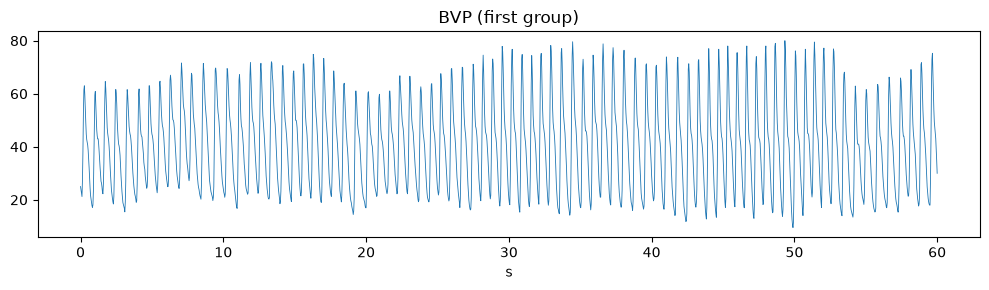

Usable rate by state:
state
post_exercise    0.997
rest             0.995

Mean cardiac SQI by state:
state
post_exercise    0.370
rest             0.456

Status counts: {'ok': np.int64(780)}


In [5]:
if OUT_H5.exists():
    with h5py.File(OUT_H5, 'r') as store:
        groups = sorted(store.keys())
        print('Groups in', OUT_H5.name, ':', len(groups))
        g0 = store[groups[0]]
        print('Example group:', groups[0])
        print('  datasets:', list(g0.keys()))
        print('  attrs:', dict(g0.attrs))
        if 'frames' in g0:
            fr = g0['frames']
            print('  frames:', fr.shape, fr.dtype, 'range', int(fr[0].min()), '-', int(fr[0].max()))
        bvp0 = g0['bvp'][:]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(np.arange(len(bvp0)) / FPS, bvp0, lw=0.6)
    ax.set_title('BVP (first group)')
    ax.set_xlabel('s')
    plt.tight_layout()
    plt.show()

if len(log):
    print('Usable rate by state:')
    print(log.groupby('state')['usable'].mean().round(3).to_string())
    print()
    print('Mean cardiac SQI by state:')
    print(log.groupby('state')['cardiac_sqi'].mean().round(3).to_string())
    print()
    print('Status counts:', dict(log['status'].value_counts()))